In [1]:
import pyarrow.parquet as pq
import numpy as np
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import IterableDataset, DataLoader
from tqdm import tqdm

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import  accuracy_score, classification_report
from torch.utils.data import DataLoader
from torch.nn import functional as F

## Config

In [2]:
# ---------------------------------------
# Configuration
# ---------------------------------------
parquet_path = 'MasterDS/Master_cleaned.parquet'
return_col   = 'ret_5d_future' # Column to predict
batch_size   = 4096
n_epochs     = 15  # number of training epochs
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ---------------------------------------
# Prepare ParquetFile and feature columns
# ---------------------------------------
pf = pq.ParquetFile(parquet_path)
all_cols = pf.schema_arrow.names
exclude  = {return_col, 'date', 'ticker'}
feature_cols = [c for c in all_cols if c not in exclude]

# ---------------------------------------
# Precompute date-wise cutoff map
# ---------------------------------------
cutoff_lists, all_dates = {}, set()
for batch in pf.iter_batches(batch_size=1_500_000):
    dfb = batch.to_pandas()[['date', return_col]]
    for date, grp in dfb.groupby('date'):
        all_dates.add(date)
        cutoff_lists.setdefault(date, []).extend(grp[return_col].values)
cutoff_map = {date: np.quantile(vals, 0.95) for date, vals in cutoff_lists.items()}
all_dates = sorted(all_dates)
n_total = len(all_dates)
train_idx = int(n_total * 0.8) # 80% for training, 20% for testing

train_dates = set(all_dates[:train_idx])
test_dates  = set(all_dates[train_idx:])


# ---------------------------------------
# Fit scaler on a sample row group
# ---------------------------------------
sample = pf.read_row_group(0).to_pandas()[feature_cols]
scaler = StandardScaler().fit(sample.values)

# ---------------------------------------
# Define IterableDataset for streaming
# ---------------------------------------
class ParquetDataset(IterableDataset):
    """
    Streams batches from the Parquet file without any class-balancing.
    Each yielded tuple is (xb, yb, meta) where:
        xb   : torch.FloatTensor  [batch_size, n_features]
        yb   : torch.FloatTensor  [batch_size]   (0/1 labels)
        meta : np.ndarray         [batch_size, 2]  (date, ticker)
    """
    def __init__(self, dates_subset, pos_ratio=None, batch_size=4096):
        self.dates_subset = dates_subset
        self.pos_ratio = pos_ratio
        self.batch_size = batch_size

    def __iter__(self):
        local_pf = pq.ParquetFile(parquet_path)

        for batch in local_pf.iter_batches(batch_size=self.batch_size * 4):
            df = batch.to_pandas()
            df = df[df["date"].isin(self.dates_subset)]
            if df.empty:
                continue

            # create label
            df["label"] = (df[return_col] >= df["date"].map(cutoff_map)).astype(np.int8)

            # filter finite rows
            X_raw = df[feature_cols].values.astype(np.float32)
            y_raw = df["label"].values.astype(np.int8)
            mask  = np.isfinite(X_raw).all(axis=1)
            if not mask.any():
                continue

            X     = scaler.transform(X_raw[mask])
            y     = y_raw[mask]
            meta  = df.loc[mask, ["date", "ticker"]].values

            if self.pos_ratio is not None:
                idx_pos = np.where(y == 1)[0]
                idx_neg = np.where(y == 0)[0]

                if len(idx_pos) == 0 or len(idx_neg) == 0:
                    continue  # skip batch if only one class

                n_pos = int(self.batch_size * self.pos_ratio)
                n_neg = self.batch_size - n_pos

                choose_pos = np.random.choice(idx_pos, n_pos, replace=len(idx_pos) < n_pos)
                choose_neg = np.random.choice(idx_neg, n_neg, replace=len(idx_neg) < n_neg)

                sel = np.concatenate([choose_pos, choose_neg])
                np.random.shuffle(sel)

                X, y, meta = X[sel], y[sel], meta[sel]
            else:
                if len(y) > self.batch_size:
                    sel = np.random.choice(len(y), self.batch_size, replace=False)
                    X, y, meta = X[sel], y[sel], meta[sel]

            # convert to tensors
            xb = torch.from_numpy(X).to(device)
            yb = torch.from_numpy(y.astype(np.float32)).to(device)

            yield xb, yb, meta


Using device: cuda


## Train

In [ ]:
# ---------------------------------------
# Create DataLoaders without multiprocessing
# ---------------------------------------
train_ds = ParquetDataset(train_dates, pos_ratio=0.30, batch_size=batch_size)

train_loader = DataLoader(train_ds, batch_size=None, num_workers=0)

# Count positives/negatives for weighting
# print("Counting positive/negative samples for pos_weight...")
# pos_count = 0
# neg_count = 0
# for batch in pf.iter_batches(batch_size=1_500_000):
#     dfb = batch.to_pandas()[['date', return_col]]
#     dfb['label'] = (dfb[return_col] >= dfb['date'].map(cutoff_map)).astype(np.int8)
#     pos_count += (dfb['label'] == 1).sum()
#     neg_count += (dfb['label'] == 0).sum()

# pos_weight_value = neg_count / max(pos_count, 1)  # avoid division by zero
# print(f"pos_weight = {pos_weight_value:.2f}")
# pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32).to(device)
# costFN = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

costFN = nn.BCEWithLogitsLoss()

class TabMLP(nn.Module):
    def __init__(self,
                 input_dim: int,
                 hidden_layers: list[int] = [512, 256, 128],
                 p_drop: float = 0.3):
        super().__init__()

        layers = []
        dim = input_dim
        for h in hidden_layers:
            layers += [
                nn.Linear(dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(p_drop)
            ]
            dim = h
        layers.append(nn.Linear(dim, 1))        # final logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):                       # x : [B, F]
        return self.net(x).squeeze(1)           # [B]
    

model = TabMLP(input_dim=len(feature_cols)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# Estimate steps per epoch
total_rows   = sum(pf.metadata.row_group(i).num_rows for i in range(pf.num_row_groups))
train_steps = int((total_rows * 0.8) // batch_size)


# ---------------------------------------
# Training loop with tqdm progress bars
# ---------------------------------------
for epoch in range(n_epochs):
    # Training
    model.train()
    train_loss, step_count = 0.0, 0
    pbar_train = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{n_epochs} Train", dynamic_ncols=True)
    for batch_idx, (X_batch, y_batch, _) in enumerate(pbar_train, 1):
        optimizer.zero_grad()
        ypreds = model(X_batch)
        loss = costFN(ypreds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        step_count += 1    # count real batches
        
    avg_train_loss = train_loss / step_count

    

    print(f"Epoch {epoch + 1}/{n_epochs} | Train Loss: {avg_train_loss:.4f}")
    current_lr = optimizer.param_groups[0]["lr"] #Slowly decay learning rate
    print(f"Epoch {epoch + 1} learning rate: {current_lr:.6f}")
    scheduler.step(avg_train_loss)


# Save trained model
torch.save(model.state_dict(), "models/TopSelector_state_dict.pt")
torch.jit.script(model).save("models/TopSelector.pt")

print("Training complete. Saved:")

Epoch 1/15 Train: 422it [01:42,  4.11it/s]


Epoch 1/15 | Train Loss: 0.5758
Epoch 1 learning rate: 0.000300


Epoch 2/15 Train: 422it [01:38,  4.30it/s]


Epoch 2/15 | Train Loss: 0.5610
Epoch 2 learning rate: 0.000300


Epoch 3/15 Train: 422it [00:49, 10.54it/s]

## Test

In [ ]:
# load model
scripted_model = torch.jit.load("models/TopSelector.pt", map_location=device)
scripted_model.to(device)
scripted_model.eval()

test_ds = ParquetDataset(test_dates)
test_loader = DataLoader(test_ds, batch_size=None, num_workers=0)

results = []
with torch.no_grad():
    for XTest, yTest, meta in test_loader:
        yTestpreds = scripted_model(XTest)
        probs = torch.sigmoid(yTestpreds).cpu().numpy()
        preds = (probs >= 0.5).astype(np.int8) # Certainty Rating
        labels = yTest.cpu().numpy()

        for i in range(len(probs)):
            date, ticker = meta[i]
            results.append((date, ticker, float(probs[i].item()), int(preds[i].item()), int(labels[i].item())))

# Build DataFrame
test_df = pd.DataFrame(results, columns=["date", "ticker", "prob", "pred", "label"])
test_df["rank_prob"] = test_df.groupby("date")["prob"].rank(method="first", ascending=False)

#Evaluation
accuracy = accuracy_score(test_df["label"], test_df["pred"])
print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(test_df["label"], test_df["pred"], digits=4))

# Export
top_150_df = test_df[test_df["rank_prob"] <= 150].copy()
top_150_df = top_150_df.sort_values(["date", "rank_prob"])
top_150_df.to_csv("top_150_predictions.csv", index=False)
print("Exported top 150 predictions per date to top_150_predictions.csv")

Test Accuracy: 0.8147

Classification Report:
               precision    recall  f1-score   support

           0     0.9726    0.8278    0.8944  18706030
           1     0.1575    0.5797    0.2478   1039224

    accuracy                         0.8147  19745254
   macro avg     0.5651    0.7037    0.5711  19745254
weighted avg     0.9297    0.8147    0.8603  19745254

Exported top 150 predictions per date to top_150_predictions.csv


Confusion matrix (rows = true class, cols = predicted) [raw counts]
          Pred 0   Pred 1
True 0  15484584  3221446
True 1    436796   602428

Confusion matrix (row-normalized, %)
        Pred 0 (%)  Pred 1 (%)
True 0       82.78       17.22
True 1       42.03       57.97

Accuracy            : 0.8147
Balanced accuracy   : 0.7037
AUC (probabilities) : 0.8058
Positives in test   : 5.26%
Predicted positives : 19.37%


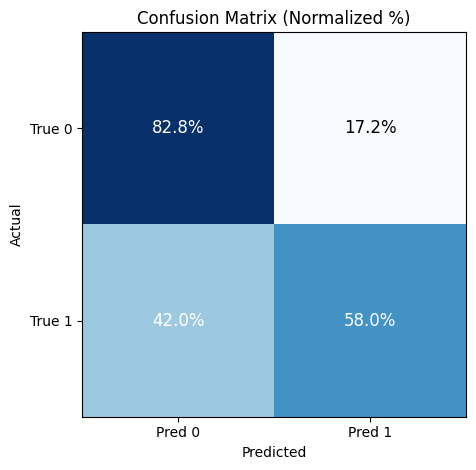

In [ ]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------
# 1. confusion-matrix + key metrics
# -------------------------------------------------
cm = confusion_matrix(test_df["label"], test_df["pred"])
tn, fp, fn, tp = cm.ravel()

# Normalize rows to percentages
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
cm_percent = np.round(cm_norm * 100, 2)

print("Confusion matrix (rows = true class, cols = predicted) [raw counts]")
print(pd.DataFrame(cm,
                   index=["True 0", "True 1"],
                   columns=["Pred 0", "Pred 1"]))

print("\nConfusion matrix (row-normalized, %)")
print(pd.DataFrame(cm_percent,
                   index=["True 0", "True 1"],
                   columns=["Pred 0 (%)", "Pred 1 (%)"]))

print(f"\nAccuracy            : {(tn+tp)/cm.sum():.4f}")
print(f"Balanced accuracy   : {balanced_accuracy_score(test_df['label'], test_df['pred']):.4f}")
print(f"AUC (probabilities) : {roc_auc_score(test_df['label'], test_df['prob']):.4f}")
print(f"Positives in test   : {test_df['label'].mean()*100:.2f}%")
print(f"Predicted positives : {(test_df['pred']==1).mean()*100:.2f}%")

# -------------------------------------------------
# 2. Heatmap of normalized confusion matrix
# -------------------------------------------------
fig, ax = plt.subplots()
im = ax.imshow(cm_percent, cmap="Blues")

# text annotations (%)
for (i, j), val in np.ndenumerate(cm_percent):
    ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
            fontsize=12, color="white" if val > cm_percent.max() / 2 else "black")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["True 0", "True 1"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Normalized %)")
plt.tight_layout()
plt.show()


## Scores

class LSTMNetwork(nn.Module):
    def __init__(self, input_size):
        super(LSTMNetwork, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=50, num_layers=2, dropout=0.2, bidirectional=True, batch_first=True)
        self.activation = nn.ReLU()
        self.fc = nn.Linear(100, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)                   # lstm_out shape: [batch, seq_len, 50]
        x = lstm_out[:, -1]                          # take last time step → shape: [batch, 50]
        x = self.activation(x)
        out = self.fc(x)                             # shape: [batch, 1]
        return out

Confusion matrix (row-normalized, %)
        Pred 0 (%)  Pred 1 (%)
True 0       82.78       17.22
True 1       42.03       57.97

Accuracy            : 0.8147
Balanced accuracy   : 0.7037
AUC (probabilities) : 0.8058
Positives in test   : 5.26%
Predicted positives : 19.37%
----------------------------------------
class LSTMNetwork(nn.Module):
    def __init__(self, input_size):
        super(LSTMNetwork, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=50, num_layers=3, dropout=0.2, batch_first=True)
        self.activation = nn.ReLU()
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)                   # lstm_out shape: [batch, seq_len, 50]
        x = lstm_out[:, -1]                          # take last time step → shape: [batch, 50]
        x = self.activation(x)
        out = self.fc(x)                             # shape: [batch, 1]
        return out

Confusion matrix (row-normalized, %)
        Pred 0 (%)  Pred 1 (%)
True 0       85.32       14.68
True 1       47.82       52.18

Accuracy            : 0.8357
Balanced accuracy   : 0.6875
AUC (probabilities) : 0.8028
Positives in test   : 5.26%
Predicted positives : 16.66%
-----------------------------------------